# 📈 Phase 4: Model Evaluation & Comparison
Comprehensive comparison of all 3 prediction systems.

In [9]:
import pandas as pd, numpy as np, pickle, warnings, os
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.metrics import (accuracy_score, roc_auc_score, classification_report,
                              mean_absolute_error, r2_score)
warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid')
print("✅ Libraries loaded")


✅ Libraries loaded


## 1️⃣ Load All Models & Data

In [ ]:
def impute_missing_values(df):
    if df.isna().sum().sum() == 0:
        return df

    num_cols = df.select_dtypes(include=[np.number]).columns
    obj_cols = df.select_dtypes(exclude=[np.number]).columns

    if len(num_cols):
        df[num_cols] = SimpleImputer(strategy='mean').fit_transform(df[num_cols])
    if len(obj_cols):
        df[obj_cols] = SimpleImputer(strategy='most_frequent').fit_transform(df[obj_cols])
    return df

# Placement
with open('models/placement_model.pkl','rb') as f:
    placement_model = pickle.load(f)
X_te_p = pd.read_csv('data/X_test_placement.csv')
X_te_p = impute_missing_values(X_te_p)
y_te_p = pd.read_csv('data/y_test_placement.csv').squeeze()

# Salary
with open('models/salary_model.pkl','rb') as f:
    salary_model = pickle.load(f)
X_te_s = pd.read_csv('data/X_test_salary.csv')
X_te_s = impute_missing_values(X_te_s)
y_te_s = pd.read_csv('data/y_test_salary.csv').squeeze()

# Burnout
with open('models/burnout_model.pkl','rb') as f:
    burnout_model = pickle.load(f)
X_te_b = pd.read_csv('data/X_test_burnout.csv')
X_te_b = impute_missing_values(X_te_b)
y_te_b = pd.read_csv('data/y_test_burnout.csv').squeeze()

print("✅ All 3 models & test data loaded!")

SyntaxError: invalid syntax (363165654.py, line 25)

## 2️⃣ Master Metrics Dashboard

In [8]:
# Placement metrics


p_pred = placement_model.predict(X_te_p)
p_prob = placement_model.predict_proba(X_te_p)[:,1]
p_acc  = accuracy_score(y_te_p, p_pred)
p_auc  = roc_auc_score(y_te_p, p_prob)

# Salary metrics
s_pred = salary_model.predict(X_te_s)
s_mae  = mean_absolute_error(y_te_s, s_pred)
s_r2   = r2_score(y_te_s, s_pred)

# Burnout metrics
b_pred = burnout_model.predict(X_te_b)
b_prob = burnout_model.predict_proba(X_te_b)[:,1]
b_acc  = accuracy_score(y_te_b, b_pred)
b_auc  = roc_auc_score(y_te_b, b_prob)

# Summary table
summary = pd.DataFrame({
    'Model':   ['Placement Prediction','Salary Forecasting','Burnout Detection'],
    'Type':    ['Classification','Regression','Classification'],
    'Primary Metric': [f'{p_acc:.4f} Accuracy', f'{s_r2:.4f} R²', f'{b_acc:.4f} Accuracy'],
    'Secondary Metric': [f'{p_auc:.4f} AUC-ROC', f'{s_mae:.2f} MAE (LPA)', f'{b_auc:.4f} AUC-ROC'],
    'Status': ['✅ Excellent' if p_acc>0.85 else '⚠️ Good',
               '✅ Excellent' if s_r2>0.80 else '⚠️ Good',
               '✅ Excellent' if b_acc>0.85 else '⚠️ Good']
})
print("╔══════════════════════════════════════════════════════════════╗")
print("║          FINAL MODEL PERFORMANCE SUMMARY                    ║")
print("╚══════════════════════════════════════════════════════════════╝")
print(summary.to_string(index=False))


ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

## 3️⃣ Visual Dashboard

NameError: name 'p_prob' is not defined

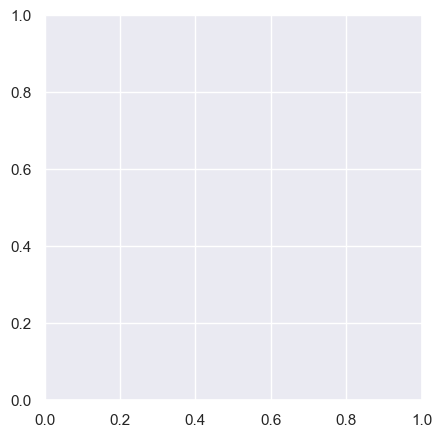

In [4]:
fig = plt.figure(figsize=(18, 12))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# — Placement: ROC curve
from sklearn.metrics import roc_curve
ax1 = fig.add_subplot(gs[0, 0])
fpr, tpr, _ = roc_curve(y_te_p, p_prob)
ax1.plot(fpr, tpr, color='#2ecc71', linewidth=2.5, label=f'AUC = {p_auc:.3f}')
ax1.fill_between(fpr, tpr, alpha=0.15, color='#2ecc71')
ax1.plot([0,1],[0,1],'k--', linewidth=1)
ax1.set_title('Placement — ROC Curve', fontweight='bold', fontsize=12)
ax1.set_xlabel('False Positive Rate'); ax1.set_ylabel('True Positive Rate')
ax1.legend()

# — Salary: Actual vs Predicted
ax2 = fig.add_subplot(gs[0, 1])
ax2.scatter(y_te_s, s_pred, alpha=0.3, color='#3498db', s=12)
mn, mx = y_te_s.min(), y_te_s.max()
ax2.plot([mn,mx],[mn,mx], 'r--', linewidth=2, label=f'R²={s_r2:.3f}')
ax2.set_title('Salary — Actual vs Predicted', fontweight='bold', fontsize=12)
ax2.set_xlabel('Actual (LPA)'); ax2.set_ylabel('Predicted (LPA)')
ax2.legend()

# — Burnout: ROC curve
ax3 = fig.add_subplot(gs[0, 2])
fpr2, tpr2, _ = roc_curve(y_te_b, b_prob)
ax3.plot(fpr2, tpr2, color='#e74c3c', linewidth=2.5, label=f'AUC = {b_auc:.3f}')
ax3.fill_between(fpr2, tpr2, alpha=0.15, color='#e74c3c')
ax3.plot([0,1],[0,1],'k--', linewidth=1)
ax3.set_title('Burnout — ROC Curve', fontweight='bold', fontsize=12)
ax3.legend()

# — Combined metrics bar
ax4 = fig.add_subplot(gs[1, :])
metrics = {
    'Placement\nAccuracy': p_acc,
    'Placement\nAUC-ROC':  p_auc,
    'Salary\nR² Score':    s_r2,
    'Burnout\nAccuracy':   b_acc,
    'Burnout\nAUC-ROC':    b_auc,
}
colors = ['#2ecc71','#27ae60','#3498db','#e74c3c','#c0392b']
bars = ax4.bar(metrics.keys(), metrics.values(), color=colors, edgecolor='white', linewidth=1.5, width=0.5)
for bar, val in zip(bars, metrics.values()):
    ax4.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
             f'{val:.3f}', ha='center', fontweight='bold', fontsize=12)
ax4.set_ylim(0, 1.15)
ax4.set_title('All Models — Performance Summary', fontsize=14, fontweight='bold')
ax4.set_ylabel('Score')
ax4.axhline(0.85, color='orange', linestyle='--', linewidth=1.5, label='Target (0.85)')
ax4.legend()

plt.suptitle('AI-Powered Student Performance Prediction System\n— Model Evaluation Dashboard —',
             fontsize=16, fontweight='bold', y=1.01)
os.makedirs('outputs', exist_ok=True)
plt.savefig('outputs/11_evaluation_dashboard.png', bbox_inches='tight', dpi=150)
plt.show()
print("✅ Saved: outputs/11_evaluation_dashboard.png")


## ✅ Final Summary

In [ ]:
print(f"""
╔══════════════════════════════════════════════════════════════════╗
║        AI-POWERED STUDENT PERFORMANCE PREDICTION SYSTEM         ║
║                    FINAL EVALUATION REPORT                      ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  📌 PLACEMENT PREDICTION                                        ║
║     Accuracy : {p_acc:.2%}                                          ║
║     AUC-ROC  : {p_auc:.4f}                                         ║
║                                                                  ║
║  📌 SALARY FORECASTING                                          ║
║     R² Score : {s_r2:.4f}                                          ║
║     MAE      : {s_mae:.2f} LPA                                      ║
║                                                                  ║
║  📌 BURNOUT RISK DETECTION                                      ║
║     Accuracy : {b_acc:.2%}                                          ║
║     AUC-ROC  : {b_auc:.4f}                                         ║
║                                                                  ║
║  Dataset: 25,000 synthetic student records (44 features)        ║
║  Models saved in: models/ folder                                ║
╚══════════════════════════════════════════════════════════════════╝
""")
